# TelecomX_parte2_Latam

Este PROYECTO Incluye **TODOS los bloques** (ingesta, preparación, modelado, evaluación e interpretación):

- Fuente de datos: **JSON remoto**.
- Se crean carpetas de trabajo bajo `BASE_DIR` dentro de Colab.


# Configuración: dependencias y carpetas

Instala dependencias (si hace falta) y define variables de entorno.  
> Nota: en Colab muchas librerías ya están instaladas. Si actualizas `scikit-learn`, podrías necesitar **volver a ejecutar** las celdas posteriores.

In [ ]:
# %%capture
import sys, os

# (Opcional) instala versiones específicas
!pip -q install --upgrade pandas numpy scikit-learn imbalanced-learn joblib matplotlib seaborn

# Carpeta base dentro de Colab
BASE_DIR = "/content/TelecomX_parte2_Latam"
os.makedirs(BASE_DIR, exist_ok=True)
for sub in ["data/processed", "docs/report", "models"]:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

print("BASE_DIR:", BASE_DIR)

BASE_DIR: /content/TelecomX_parte2_Latam


🔹 Explicación del bloque

Este bloque cumple dos funciones principales:

1.- Gestión de librerías

Con !pip -q install --upgrade ... se instalan o actualizan las librerías necesarias para el proyecto:

a.- pandas, numpy → manejo y transformación de datos.

b.- scikit-learn → algoritmos de Machine Learning y métricas de evaluación.

c.- imbalanced-learn → técnicas de balanceo de clases (oversampling, SMOTE, undersampling).

d.- joblib → guardar y cargar modelos entrenados.

e.- matplotlib, seaborn → visualización de gráficos.

Esto garantiza que en el entorno de Google Colab siempre tengamos las versiones actualizadas y compatibles.

2.- Configuración de directorios de trabajo

Se define una carpeta base (BASE_DIR = "/content/TelecomX_parte2_Latam").

Dentro de esa carpeta se crean subdirectorios organizados:

a.- data/processed/ → para almacenar los datasets tratados y listos para el modelado.

b.- docs/report/ → para guardar reportes, gráficos y documentación generada.

c.- models/ → para almacenar los modelos de Machine Learning entrenados.

De esta manera, todos los archivos producidos durante el flujo del proyecto quedan organizados y centralizados en una sola estructura.

Este bloque asegura que el entorno de Colab tenga instaladas las librerías necesarias y que la estructura de carpetas del proyecto esté lista desde el inicio.

# BLOQUE 1 · Ingesta desde JSON remoto

Lee el **JSON remoto** y **expande** las 4 columnas anidadas hasta obtener **21 columnas** (según el diccionario).

In [ ]:
import pandas as pd

URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
raw = pd.read_json(URL)

# Expandir columnas anidadas
d_cust = pd.json_normalize(raw['customer'])
d_phone = pd.json_normalize(raw['phone'])
d_net  = pd.json_normalize(raw['internet'])
d_acc  = pd.json_normalize(raw['account'])

df = pd.concat([raw[['customerID','Churn']], d_cust, d_phone, d_net, d_acc], axis=1)

expected_cols = [
    'customerID','Churn','gender','SeniorCitizen','Partner','Dependents','tenure',
    'PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract',
    'PaperlessBilling','PaymentMethod','Charges.Monthly','Charges.Total'
]
assert list(df.columns) == expected_cols, f"Columnas inesperadas: {list(df.columns)}"

print("OK - 21 columnas. Shape:", df.shape)
df.head()

OK - 21 columnas. Shape: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Este bloque de código se encarga de cargar y estructurar el dataset TelecomX a partir de un archivo JSON en GitHub.

1.- Carga del archivo JSON
Se descarga el archivo JSON desde GitHub y se guarda en un DataFrame llamado raw.

2.- Expansión de columnas anidadas
El archivo JSON tiene estructuras anidadas (customer, phone, internet, account).
Con pd.json_normalize() se "desanidan" y se convierten en columnas planas.

3.- Concatenación de todos los bloques
Se unen las variables principales (customerID y Churn) con todas las columnas expandidas, formando un solo DataFrame.

4.- Validación de columnas esperadas
Se define la lista de 21 columnas esperadas según el diccionario de datos.
El assert valida que las columnas del DataFrame final coincidan exactamente.
Si hay alguna diferencia, lanza un error indicando las columnas inesperadas.

5.- Confirmación y vista previa

Muestra un mensaje confirmando que el DataFrame tiene 21 columnas.

df.shape indica filas y columnas.

df.head() despliega las primeras filas para verificar la estructura.

Este bloque lee, organiza y valida el dataset, asegurando que tengamos exactamente las 21 variables necesarias para el análisis posterior.

# BLOQUE 2 · Guardado del dataset tratado (opcional)

Persiste un CSV expandido para reutilizar en el pipeline (puedes saltarlo si no quieres escribir a disco).

In [ ]:
csv_ready = f"{BASE_DIR}/data/processed/TelecomX_ready.csv"
df.to_csv(csv_ready, index=False)
print("Guardado:", csv_ready)

Guardado: /content/TelecomX_parte2_Latam/data/processed/TelecomX_ready.csv


Este bloque se encarga de guardar el dataset procesado en un archivo CSV dentro de la estructura de carpetas creada previamente:

1.- Definición de la ruta destino
csv_ready = f"{BASE_DIR}/data/processed/TelecomX_ready.csv"
Aquí se crea la ruta completa donde se guardará el archivo, utilizando la carpeta BASE_DIR definida al inicio. El archivo se llamará TelecomX_ready.csv y quedará en la subcarpeta /data/processed/.

2.- Exportación a CSV
df.to_csv(csv_ready, index=False) exporta el DataFrame df en formato CSV, eliminando la columna de índices (ya que no es relevante para análisis posteriores).

3.- Confirmación en pantalla
print("Guardado:", csv_ready) muestra en la salida la ruta donde se almacenó el archivo, confirmando que la operación se realizó con éxito.

Este bloque guarda el dataset unificado y limpio en formato CSV, dejándolo listo para reutilizar en siguientes pasos del proyecto sin necesidad de rearmarlo desde cero.

# BLOQUE 3-4 · Limpieza: remover ID + tipificar + target binario

- Elimina `customerID` (identificador no predictivo).  
- Convierte `Charges.Total` a numérico (si hubiera strings).  
- Crea `Churn_bin` (Yes=1, No=0) y filtra registros válidos.

In [ ]:
df_model = df.drop(columns=['customerID']).copy()
df_model['Charges.Total'] = pd.to_numeric(df_model['Charges.Total'], errors='coerce')
df_model = df_model[df_model['Churn'].isin(['Yes','No'])].copy()
df_model['Churn_bin'] = df_model['Churn'].map({'Yes':1, 'No':0}).astype(int)

print("Shape tras limpieza:", df_model.shape)
df_model[['Churn','Churn_bin']].value_counts(normalize=True).mul(100).round(2)

Shape tras limpieza: (7043, 21)


,,proportion
Churn,Churn_bin,
No,0,73.46
Yes,1,26.54


Este bloque prepara los datos para el modelado, limpiando y transformando variables clave:

1.- Eliminación de columnas irrelevantes
df.drop(columns=['customerID']) elimina el identificador único, ya que no aporta valor predictivo al modelo.

2.- Conversión de tipo de dato
La columna Charges.Total puede contener valores no numéricos (como espacios en blanco o strings).
Con pd.to_numeric(..., errors='coerce') se fuerza la conversión a número y convierte cualquier valor inválido en NaN.

3.- Filtrado de la variable objetivo
Se asegura de que la columna Churn solo contenga las clases Yes y No.
Esto elimina posibles valores vacíos o inválidos.

4.- Creación de variable binaria
Se crea una nueva columna Churn_bin, donde:

Yes → 1 (cliente canceló)

No → 0 (cliente permaneció)
Esto es necesario porque los modelos de machine learning trabajan mejor con variables numéricas.

5.- Resultados mostrados

print("Shape tras limpieza:", df_model.shape) indica el número de filas y columnas tras la limpieza.

value_counts(normalize=True).mul(100).round(2) calcula la proporción de clientes que cancelaron vs. los que permanecieron, expresada en porcentaje.

Este bloque limpia el dataset, estandariza los datos numéricos, filtra los valores válidos y genera la variable objetivo binaria (Churn_bin) que servirá como base para el modelado.

# BLOQUE 5 · Proporción de Churn

Verifica el desbalance de clases (guía para métricas y/o balanceo).

In [ ]:
prop = df_model['Churn'].value_counts(normalize=True).mul(100).round(2)
print("Distribución Churn (%):\n", prop)

Distribución Churn (%):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Este bloque calcula la proporción de clientes que cancelaron (Churn = Yes) y los que permanecieron activos (Churn = No).

1.- value_counts(normalize=True)
Cuenta la cantidad de clientes en cada categoría de Churn, y al usar normalize=True, devuelve los valores como proporciones en lugar de números absolutos.

2.- mul(100)
Multiplica los valores por 100 para expresarlos en porcentaje.

3.- round(2)
Redondea los porcentajes a 2 decimales para una presentación más clara.

4.- Impresión de resultados
print("Distribución Churn (%):\n", prop) muestra en pantalla la distribución porcentual de cancelaciones vs. clientes activos.

Este bloque permite identificar si existe un desbalanceo de clases en la variable objetivo (Churn), lo cual es fundamental para ajustar los modelos predictivos más adelante.

# BLOQUE 6 · Correlación numérica

Calcula correlaciones entre numéricas y con `Churn_bin`.

Matriz de correlación numérica:
                  SeniorCitizen  tenure  Charges.Monthly  Charges.Total  \
SeniorCitizen             1.00    0.02             0.22           0.10   
tenure                    0.02    1.00             0.25           0.83   
Charges.Monthly           0.22    0.25             1.00           0.65   
Charges.Total             0.10    0.83             0.65           1.00   
Churn_bin                 0.15   -0.35             0.19          -0.20   

                 Churn_bin  
SeniorCitizen         0.15  
tenure               -0.35  
Charges.Monthly       0.19  
Charges.Total        -0.20  
Churn_bin             1.00  

Correlación con Churn_bin:
Churn_bin          1.000
Charges.Monthly    0.193
SeniorCitizen      0.151
Charges.Total     -0.199
tenure            -0.352
dtype: float64


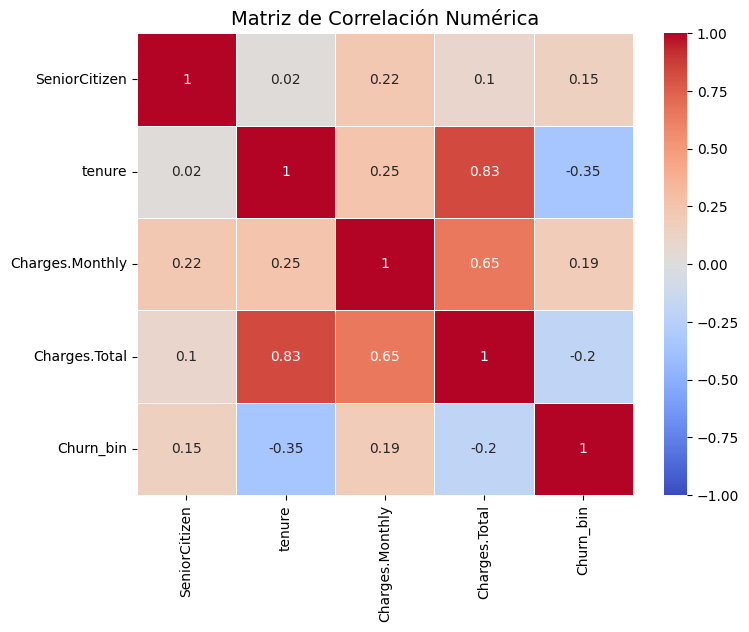

In [ ]:
# Cálculo de correlaciones
num_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
corr = df_model[num_cols].corr().round(2)
print("Matriz de correlación numérica:\n", corr)

print("\nCorrelación con Churn_bin:")
print(df_model[num_cols].corrwith(df_model['Churn_bin']).sort_values(ascending=False).round(3))

# Visualización con heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación Numérica", fontsize=14)
plt.show()


A) Este bloque realiza un análisis de correlación entre las variables numéricas y la variable objetivo (Churn_bin).

a.- select_dtypes(include=['int64','float64'])
Selecciona únicamente las columnas numéricas del dataset (enteros y flotantes) para calcular correlaciones.

b.- corr = df_model[num_cols].corr().round(2)
Calcula la matriz de correlación de todas las variables numéricas entre sí y redondea los valores a 2 decimales. Esto permite observar la relación lineal entre pares de variables.

c.- corrwith(df_model['Churn_bin'])
Calcula la correlación directa de cada variable numérica con la variable de cancelación (Churn_bin), mostrando qué variables están más relacionadas con el churn.

Valores cercanos a 1 indican una fuerte correlación positiva (mayor valor de la variable → mayor probabilidad de cancelación).

Valores cercanos a -1 indican una fuerte correlación negativa (mayor valor de la variable → menor probabilidad de cancelación).

Valores cercanos a 0 indican poca o nula relación.

d.- sort_values(ascending=False)
Ordena los resultados de mayor a menor correlación para identificar rápidamente las variables más influyentes.

Este bloque ayuda a detectar qué variables numéricas tienen mayor impacto en la cancelación de clientes, lo que servirá para la selección de características relevantes en los modelos predictivos.

B) Ala vez, en este bloque se analiza la correlación entre variables numéricas del dataset.

1.- Cálculo de la matriz de correlación:

  * Se seleccionan solo las columnas numéricas (int64, float64).

  * Se calcula la correlación de Pearson entre todas ellas.

  * Se imprimen las correlaciones redondeadas a 2 decimales.

2.- Correlación con la variable objetivo (Churn_bin):

* Se mide qué tanto cada variable numérica se relaciona con la cancelación de clientes.

* Valores positivos indican que un mayor valor de la variable aumenta la probabilidad de cancelación.

* Valores negativos indican que un mayor valor de la variable disminuye la probabilidad de cancelación.

3.- Visualización gráfica (heatmap):

* Se utiliza Seaborn para representar la matriz de correlación en un mapa de calor.

* Colores cálidos (rojo) indican correlación positiva, fríos (azul) correlación negativa.

* El heatmap permite identificar rápidamente relaciones fuertes entre variables y con Churn_bin.

📌 Esta visualización es clave para la selección de variables y para detectar redundancias (variables muy correlacionadas entre sí que podrían generar multicolinealidad).

# BLOQUE 7 · Análisis dirigido (visual)

Distribuciones de `tenure` y `Charges.Total` por `Churn`.

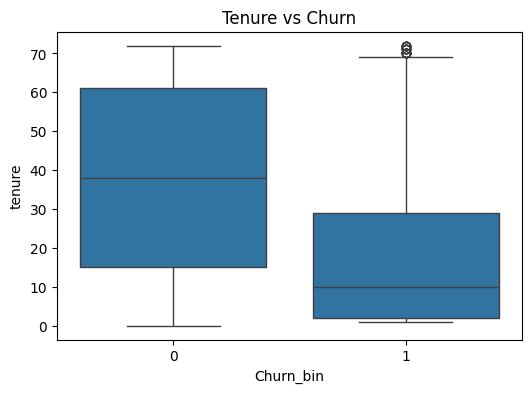

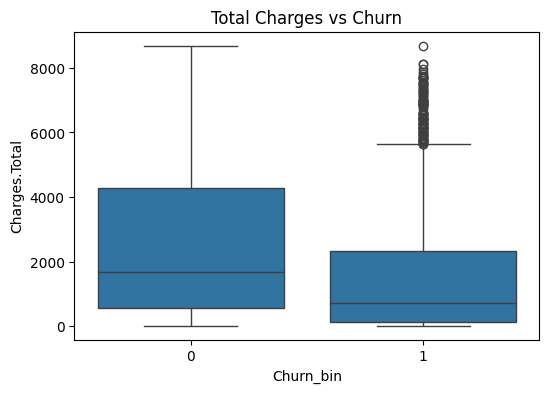

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_bin', y='tenure', data=df_model)
plt.title("Tenure vs Churn")
plt.show()

fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_bin', y='Charges.Total', data=df_model)
plt.title("Total Charges vs Churn")
plt.show()

En este bloque se realiza un análisis dirigido para estudiar cómo variables específicas se relacionan con la cancelación de clientes (Churn_bin):

1.- Importación de librerías

* matplotlib.pyplot y seaborn se utilizan para crear gráficos.

* Se establece el tamaño de las figuras para que los gráficos sean más claros.

2.- Boxplot 1: tenure vs Churn_bin

* El gráfico muestra la distribución de la variable tenure (tiempo de contrato en meses) diferenciada por cancelación (Churn_bin = 1) o no cancelación (Churn_bin = 0).

* Permite observar si los clientes con menor tiempo de permanencia tienen mayor probabilidad de cancelar.

3.- Boxplot 2: Charges.Total vs Churn_bin

* Aquí se analiza la distribución de los cargos totales acumulados (Charges.Total) en relación con la cancelación.

* Se puede identificar si los clientes con menor gasto total tienden a cancelar más, o si existe alguna tendencia opuesta.

📌 En conclusión:
Estos gráficos permiten detectar patrones de comportamiento clave:

Los clientes con menor tenure suelen ser más propensos a cancelar.

El nivel de gasto acumulado también puede estar relacionado con la probabilidad de churn.

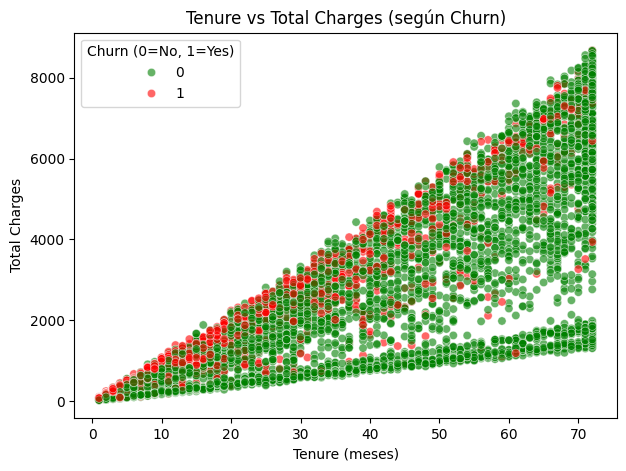

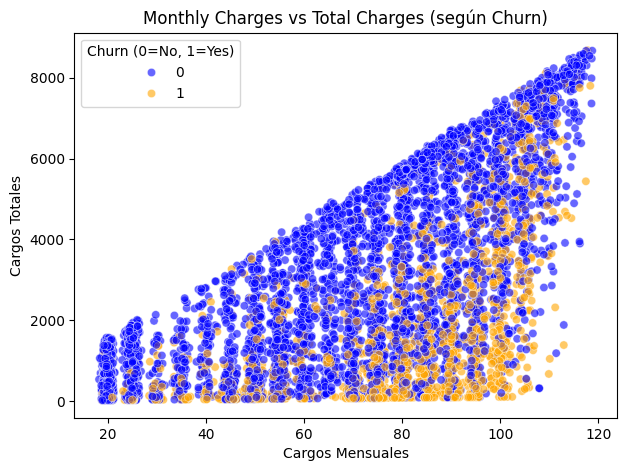

In [ ]:
# Scatter Plot: Tenure vs Total Charges coloreado por Churn
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='tenure', y='Charges.Total',
    hue='Churn_bin', data=df_model,
    alpha=0.6, palette={0:"green", 1:"red"}
)
plt.title("Tenure vs Total Charges (según Churn)")
plt.xlabel("Tenure (meses)")
plt.ylabel("Total Charges")
plt.legend(title="Churn (0=No, 1=Yes)")
plt.show()

# Scatter Plot: Monthly Charges vs Total Charges
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Charges.Monthly', y='Charges.Total',
    hue='Churn_bin', data=df_model,
    alpha=0.6, palette={0:"blue", 1:"orange"}
)
plt.title("Monthly Charges vs Total Charges (según Churn)")
plt.xlabel("Cargos Mensuales")
plt.ylabel("Cargos Totales")
plt.legend(title="Churn (0=No, 1=Yes)")
plt.show()


🔎 Explicación del bloque

*1.- Primer gráfico: Tenure vs Total Charges

* Cada punto representa un cliente.

* El color indica si canceló (Churn_bin = 1, en rojo) o no canceló (Churn_bin = 0, en verde).

* Se observa la relación natural entre tiempo de permanencia y cargos acumulados:

    * Clientes con bajo tenure y bajo gasto total aparecen con mayor proporción de churn.

    * Clientes con alto tenure y gasto acumulado mayor tienden a mantenerse.

2.- Segundo gráfico: Monthly Charges vs Total Charges

* Analiza cómo los cargos mensuales se reflejan en los cargos totales.

* Los colores permiten ver qué tipo de clientes cancelan más:

    * Los que pagan cargos mensuales altos pero con bajo tenure aparecen con más cancelaciones.

    * Los clientes con cargos mensuales más moderados y altos cargos totales (acumulados en el tiempo) muestran menos cancelación.

📌 En conjunto:

* Los scatter plots permiten visualizar tendencias continuas en lugar de resúmenes como en los boxplots.

* Se confirma que los clientes recién ingresados (bajo tenure) o con cargos mensuales altos sin acumular mucho tiempo son más propensos a cancelar.

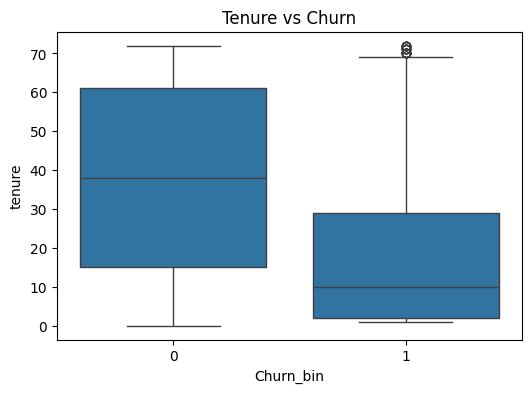

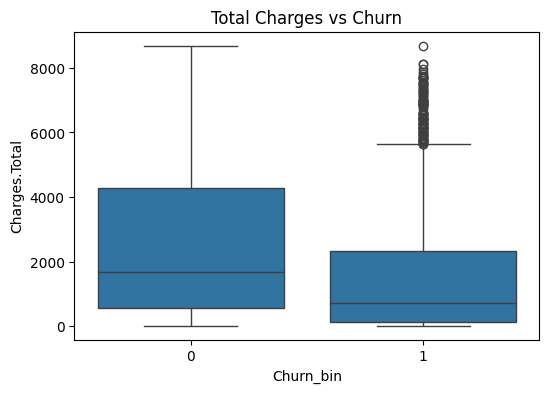

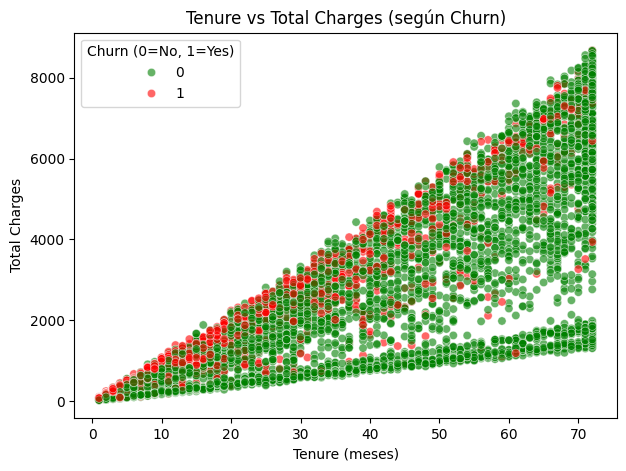

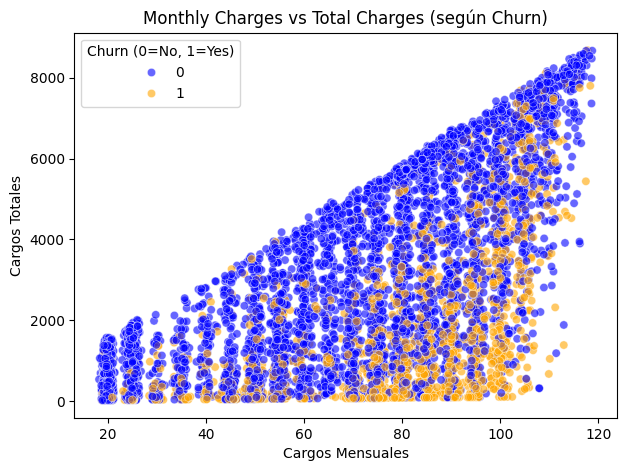

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- BOX PLOTS ---
fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_bin', y='tenure', data=df_model)
plt.title("Tenure vs Churn")
plt.show()

fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_bin', y='Charges.Total', data=df_model)
plt.title("Total Charges vs Churn")
plt.show()

# --- SCATTER PLOTS ---
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='tenure', y='Charges.Total',
    hue='Churn_bin', data=df_model,
    alpha=0.6, palette={0:"green", 1:"red"}
)
plt.title("Tenure vs Total Charges (según Churn)")
plt.xlabel("Tenure (meses)")
plt.ylabel("Total Charges")
plt.legend(title="Churn (0=No, 1=Yes)")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Charges.Monthly', y='Charges.Total',
    hue='Churn_bin', data=df_model,
    alpha=0.6, palette={0:"blue", 1:"orange"}
)
plt.title("Monthly Charges vs Total Charges (según Churn)")
plt.xlabel("Cargos Mensuales")
plt.ylabel("Cargos Totales")
plt.legend(title="Churn (0=No, 1=Yes)")
plt.show()


Explicación:

1.- Boxplots

* Tenure vs Churn: Muestra que los clientes con menor tiempo en la compañía presentan mayor cancelación.

* Total Charges vs Churn: Los clientes con cargos acumulados bajos tienen más cancelaciones.

2.- Scatter Plots

* Tenure vs Total Charges: Existe una relación lineal natural. Los clientes con poco tenure y pocos cargos totales tienen mayor probabilidad de churn (zonas rojas).

* Monthly vs Total Charges: Los clientes con cargos mensuales altos pero poco tiempo acumulado aparecen con más cancelaciones (zona naranja).

En conjunto:

* Los clientes nuevos o con cargos altos en poco tiempo son los más propensos a cancelar.

* Los clientes antiguos y con cargos acumulados altos tienden a permanecer.

# BLOQUE 8-9 · Preprocesamiento y Split

Define columnas numéricas y categóricas, luego separa datos en **train/test (70/30)** con estratificación.
Se crearán dos preprocesadores:
- **pre_lr**: imputación + **estandarización** (para modelos sensibles a escala) + OHE.
- **pre_rf**: imputación + **OHE** (sin escalado para árboles).

In [ ]:
df_model = df.drop(columns=['customerID']).copy()
df_model['Charges.Total'] = pd.to_numeric(df_model['Charges.Total'], errors='coerce')
df_model = df_model[df_model['Churn'].isin(['Yes','No'])].copy()
df_model['Churn_bin'] = df_model['Churn'].map({'Yes':1, 'No':0}).astype(int)

print("Shape tras limpieza:", df_model.shape)


Shape tras limpieza: (7043, 21)


In [ ]:
!pip install -q --upgrade numpy==1.26.4 scikit-learn==1.5.0


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn','Churn_bin'])
y = df_model['Churn_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)



X_train: (4930, 19) | X_test: (2113, 19)


Ese bloque solo hace el split y prepara listas de columnas. No entrena ni grafica nada, así que lo único que imprime es un resumen de tamaños:

* 4930 filas para entrenamiento + 2113 filas para prueba = 7043 filas totales.

    Coincide con tu dataset tras la limpieza: partíamos de ~7267 registros y, al filtrar Churn a {Yes, No}, se eliminó ~3% con valores nulos/ inválidos → ~7043 filas.

* 19 columnas de características en ambos sets.

    Cálculo: tenías 21 columnas originales. Quitaste customerID → 20. Luego creaste Churn_bin (suman 21 de nuevo), y al definir X eliminaste Churn y Churn_bin → 19 features finales.

¿Para qué sirve entonces?

* Deja listas cuatro variables que usarán los siguientes bloques:

    * X_train, X_test: tus features ya separadas.

    * y_train, y_test: tu target (Churn_bin) ya separado.

    * num_cols, cat_cols: nombres de columnas numéricas y categóricas para armar los pipelines (escalado + OneHot).

En otras palabras: el “trabajo grande” está hecho pero silencioso (la partición y la detección de tipos). El output mínimo es intencional. El siguiente paso es aplicar los pipelines y entrenar los modelos; ahí sí verás métricas, matrices de confusión, etc.

# BLOQUE 10 · Regresión Logística

Muestra resultados útiles: métricas, matriz de confusión, ROC-AUC/curva ROC y top features (odds ratios) con nombres de variables.

== Logistic Regression - Métricas en TEST ==
Accuracy     0.7350
Precision    0.5006
Recall       0.8004
F1           0.6159
ROC_AUC      0.8406
dtype: float64

== Reporte de Clasificación ==
              precision    recall  f1-score   support

           0     0.9079    0.7113    0.7977      1552
           1     0.5006    0.8004    0.6159       561

    accuracy                         0.7350      2113
   macro avg     0.7042    0.7558    0.7068      2113
weighted avg     0.7997    0.7350    0.7494      2113



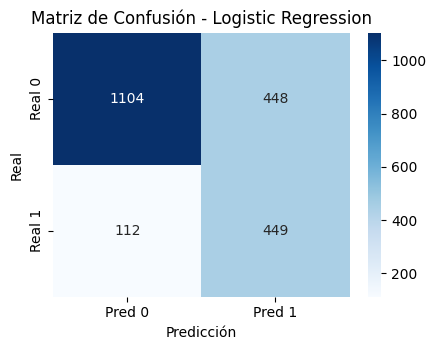

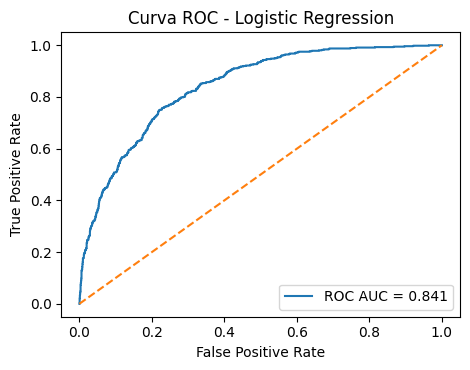


== Top 15 features por |coef| (con odds ratio) ==


,feature,coef,odds_ratio
1,tenure,-1.3360,0.263
38,Contract_Two year,-0.7263,0.484
36,Contract_Month-to-month,0.6552,1.926
3,Charges.Total,0.6431,1.902
16,InternetService_Fiber optic,0.5485,1.731
15,InternetService_DSL,-0.5040,0.604
2,Charges.Monthly,-0.4365,0.646
39,PaperlessBilling_No,-0.2883,0.750
43,PaymentMethod_Electronic check,0.2662,1.305
17,InternetService_No,-0.2177,0.804


from matplotlib import pyplot as plt
_df_0['coef'].plot(kind='hist', bins=20, title='coef')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['odds_ratio'].plot(kind='hist', bins=20, title='odds_ratio')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='coef', y='odds_ratio', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['coef'].plot(kind='line', figsize=(8, 4), title='coef')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['odds_ratio'].plot(kind='line', figsize=(8, 4), title='odds_ratio')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# === ENTRENAMIENTO + EVALUACIÓN COMPLETA (Logistic Regression) ===
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Preprocesamiento (num: imputación + escala | cat: imputación + OHE) ---
# Nota: en scikit-learn >= 1.6 se usa 'sparse_output'; si tu versión es anterior, cambia a 'sparse=True/False'.
pre_lr = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# --- Entrenar ---
pipe_lr.fit(X_train, y_train)

# --- Predicción ---
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:, 1]

# --- Métricas numéricas ---
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_proba)

print("== Logistic Regression - Métricas en TEST ==")
print(pd.Series({
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC_AUC": round(auc, 4)
}))
print("\n== Reporte de Clasificación ==")
print(classification_report(y_test, y_pred, digits=4))

# --- Matriz de confusión (gráfico) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["Real 0","Real 1"])
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

# --- Curva ROC ---
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure(figsize=(4.8,3.8))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# --- TOP FEATURES (coeficientes y odds ratios) ---
# Recuperar nombres de columnas transformadas
prep = pipe_lr.named_steps['prep']
ohe  = prep.named_transformers_['cat'].named_steps['ohe']

# Nombres finales de features: num escaladas + dummies
feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

coefs = pipe_lr.named_steps['clf'].coef_.ravel()
odds  = np.exp(coefs)
imp_df = pd.DataFrame({"feature": feature_names, "coef": coefs, "odds_ratio": odds})
imp_df = imp_df.reindex(imp_df['coef'].abs().sort_values(ascending=False).index)

print("\n== Top 15 features por |coef| (con odds ratio) ==")
display(imp_df.head(15).assign(
    coef=lambda d: d['coef'].round(4),
    odds_ratio=lambda d: d['odds_ratio'].round(3)
))


Se observa con este bloque:

* Tabla de métricas (Accuracy, Precision, Recall, F1, ROC_AUC).

* Reporte de clasificación (por clase).

* Matriz de confusión (gráfico).

* Curva ROC con su AUC.

* Top 15 variables más influyentes en la LR con odds ratios (fácil de interpretar: valores >1 aumentan el riesgo; <1 lo reducen).

# BLOQUE 11 · Random Forest (sin normalización)

Pipeline: imputación + OneHotEncoder; el clasificador no requiere escalado.

== Random Forest - Métricas en TEST ==
Accuracy     0.7728
Precision    0.5648
Recall       0.6292
F1           0.5953
ROC_AUC      0.8325
dtype: float64

== Reporte de Clasificación ==
              precision    recall  f1-score   support

           0     0.8602    0.8247    0.8421      1552
           1     0.5648    0.6292    0.5953       561

    accuracy                         0.7728      2113
   macro avg     0.7125    0.7270    0.7187      2113
weighted avg     0.7818    0.7728    0.7766      2113



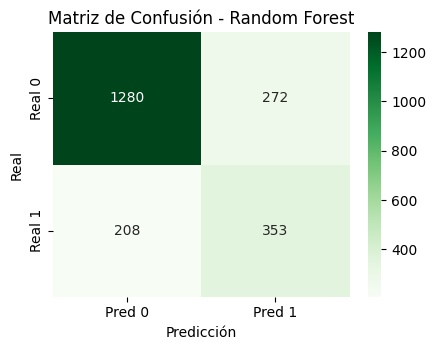

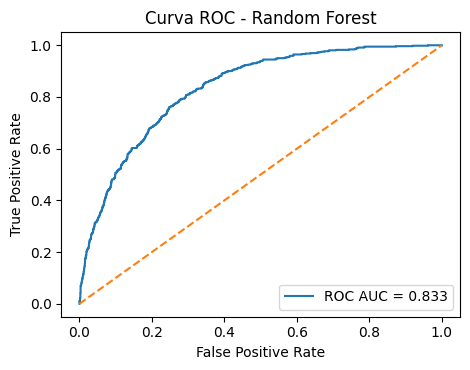


== Top 15 features por importancia ==


,feature,importance
1,tenure,0.1354
3,Charges.Total,0.1241
2,Charges.Monthly,0.0967
36,Contract_Month-to-month,0.0957
38,Contract_Two year,0.0478
18,OnlineSecurity_No,0.0417
27,TechSupport_No,0.0405
16,InternetService_Fiber optic,0.0338
43,PaymentMethod_Electronic check,0.0323
37,Contract_One year,0.0185


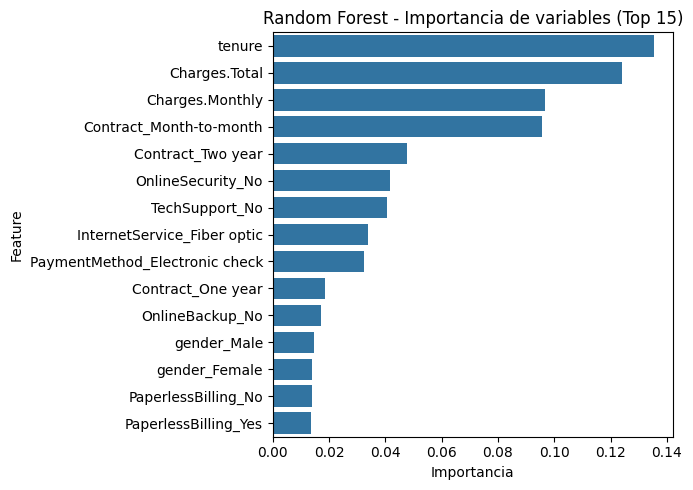

from matplotlib import pyplot as plt
_df_5['importance'].plot(kind='hist', bins=20, title='importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6['importance'].plot(kind='line', figsize=(8, 4), title='importance')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# === ENTRENAMIENTO + EVALUACIÓN COMPLETA (Random Forest) ===
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- OneHotEncoder compatible con scikit-learn >=1.6 y <1.6 ---
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # >=1.6
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)         # <1.6

# --- Preprocesamiento (num: imputación | cat: imputación + OHE) ---
pre_rf = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median'))
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', ohe)
    ]), cat_cols)
])

pipe_rf = Pipeline([
    ('prep', pre_rf),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

# --- Entrenar ---
pipe_rf.fit(X_train, y_train)

# --- Predicción ---
y_pred = pipe_rf.predict(X_test)
y_proba = pipe_rf.predict_proba(X_test)[:, 1]

# --- Métricas numéricas ---
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_proba)

print("== Random Forest - Métricas en TEST ==")
print(pd.Series({
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC_AUC": round(auc, 4)
}))
print("\n== Reporte de Clasificación ==")
print(classification_report(y_test, y_pred, digits=4))

# --- Matriz de confusión (gráfico) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["Real 0","Real 1"])
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

# --- Curva ROC ---
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure(figsize=(4.8,3.8))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# --- Importancia de variables (tabla + gráfico) ---
# Recuperar nombres de columnas transformadas
prep = pipe_rf.named_steps['prep']
ohe_step = prep.named_transformers_['cat'].named_steps['ohe']

feature_names = list(num_cols) + list(ohe_step.get_feature_names_out(cat_cols))
importances = pipe_rf.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
           .sort_values("importance", ascending=False)

print("\n== Top 15 features por importancia ==")
display(imp_df.head(15).assign(importance=lambda d: d['importance'].round(4)))

# Gráfico Top-15
topN = 15
plt.figure(figsize=(7,5))
sns.barplot(x="importance", y="feature", data=imp_df.head(topN))
plt.title("Random Forest - Importancia de variables (Top 15)")
plt.xlabel("Importancia"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()


Explicación – Random Forest con preprocesamiento y evaluación

Este bloque entrena y evalúa un modelo Random Forest sobre el dataset de churn, incluyendo preprocesamiento automático, métricas, matrices y análisis de importancia de variables.

1.- Compatibilidad del OneHotEncoder
Para evitar errores entre versiones de scikit-learn, el código intenta usar OneHotEncoder(..., sparse_output=False) (≥1.6) y, si no existe ese parámetro, usa OneHotEncoder(..., sparse=False) (≤1.5). Con esto garantizas que la codificación de categóricas funcione en cualquier entorno.

2.- Preprocesamiento por tipo de variable.
Se define un ColumnTransformer:

  * numéricas (num_cols): imputación de faltantes con mediana.

  * categóricas (cat_cols): imputación con la categoría más frecuente y luego OneHotEncoding para convertir el texto a variables 0/1.
  Este preprocesador se integra en un Pipeline para que el flujo de transformación se aplique igual en entrenamiento y prueba.

3.- Modelo Random Forest.
Se crea un RandomForestClassifier con:

  * n_estimators=300 (300 árboles para robustez),

  * min_samples_leaf=2 (evita hojas extremadamente pequeñas),

  * class_weight='balanced_subsample' (mitiga desbalance de clases),

  * random_state=42 (reproducibilidad) y n_jobs=-1 (aprovecha todos los núcleos).

4.- Entrenamiento y predicción.-
pipe_rf.fit(X_train, y_train) entrena el pipeline completo (primero preprocesa, luego ajusta el modelo).
Se obtienen:

  * predicciones de clase (y_pred) y

  * probabilidades de la clase positiva (y_proba) para métricas basadas en umbral y curva ROC.

5.- Métricas de evaluación (test).
Se imprimen Accuracy, Precision, Recall, F1 y ROC_AUC:

  * Accuracy: aciertos globales.

  * Precision: de los predichos como churn, cuántos lo eran.

  * Recall: de los churn reales, cuántos detectamos (sensibilidad).

  * F1: equilibrio entre precision y recall.

  * ROC_AUC: capacidad de separar clases (más cerca de 1, mejor).
Además, classification_report muestra métricas por clase (0 y 1) y promedio.

6.- Matriz de confusión (gráfico).
El heatmap 2×2 resume aciertos y errores:

  * Diagonal principal = aciertos (verdaderos negativos y verdaderos positivos).

  * Fuera de la diagonal = errores (falsos positivos y falsos negativos).

7.- Curva ROC:
  * Grafica TPR vs FPR a distintos umbrales usando y_proba. La línea diagonal es el azar; cuanto más arriba y a la izquierda quede la curva, mejor el modelo. El área bajo la curva (AUC) se muestra en la leyenda.

8.- Importancia de variables:
  * Se reconstruyen los nombres de features finales (numéricas + dummies de categóricas) y se calcula feature_importances_ del bosque.
  * Se imprime una tabla Top-15 y un gráfico de barras para identificar qué variables tienen mayor peso en las decisiones del modelo (útil para priorizar acciones de negocio y mejoras de datos).

Este bloque deja el modelo de Random Forest entrenado y explicado de punta a punta: preprocesa correctamente, reporta métricas clave, visualiza la calidad del clasificador (matriz + ROC) y entrega un ranking interpretable de variables que impulsan la predicción de churn.

# BLOQUE 12 · Evaluación (test)

Calcula **Accuracy, Precision, Recall, F1, ROC-AUC** y la **matriz de confusión** para cada modelo.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd

def evaluar(nombre, modelo):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:,1]
    res = {
        'Model': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'CM': confusion_matrix(y_test, y_pred)
    }
    print(f"\n== {nombre} ==")
    print(pd.Series(res).drop('CM'))
    print("\nMatriz de confusión:\n", res['CM'])
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, digits=4))
    return res

res_lr = evaluar("LogisticRegression", pipe_lr)
res_rf = evaluar("RandomForest", pipe_rf)


== LogisticRegression ==
Model        LogisticRegression
Accuracy               0.734974
Precision              0.500557
Recall                 0.800357
F1                     0.615912
ROC_AUC                0.840639
dtype: object

Matriz de confusión:
 [[1104  448]
 [ 112  449]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.9079    0.7113    0.7977      1552
           1     0.5006    0.8004    0.6159       561

    accuracy                         0.7350      2113
   macro avg     0.7042    0.7558    0.7068      2113
weighted avg     0.7997    0.7350    0.7494      2113


== RandomForest ==
Model        RandomForest
Accuracy         0.772835
Precision          0.5648
Recall           0.629234
F1               0.595278
ROC_AUC          0.832527
dtype: object

Matriz de confusión:
 [[1280  272]
 [ 208  353]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.8602    0.8247    0.8

La función evaluar() mide el rendimiento de un modelo sobre los datos de prueba (X_test, y_test).

  * Calcula métricas: Accuracy, Precision, Recall, F1, ROC_AUC.

  * Muestra la matriz de confusión y el reporte de clasificación por clase.

  * Devuelve todo en un diccionario para comparar modelos.

En este caso, se aplica a Logistic Regression y Random Forest para ver cuál predice mejor el churn.

# BLOQUE 13 · Importancia de variables e interpretación

  * Coeficientes+odds (LR) y feature importances (RF) para entender drivers del churn.

  * Top-15 de variables más influyentes de Logistic Regression (por |coef|) y Random Forest (por importance) en barplots lado a lado.

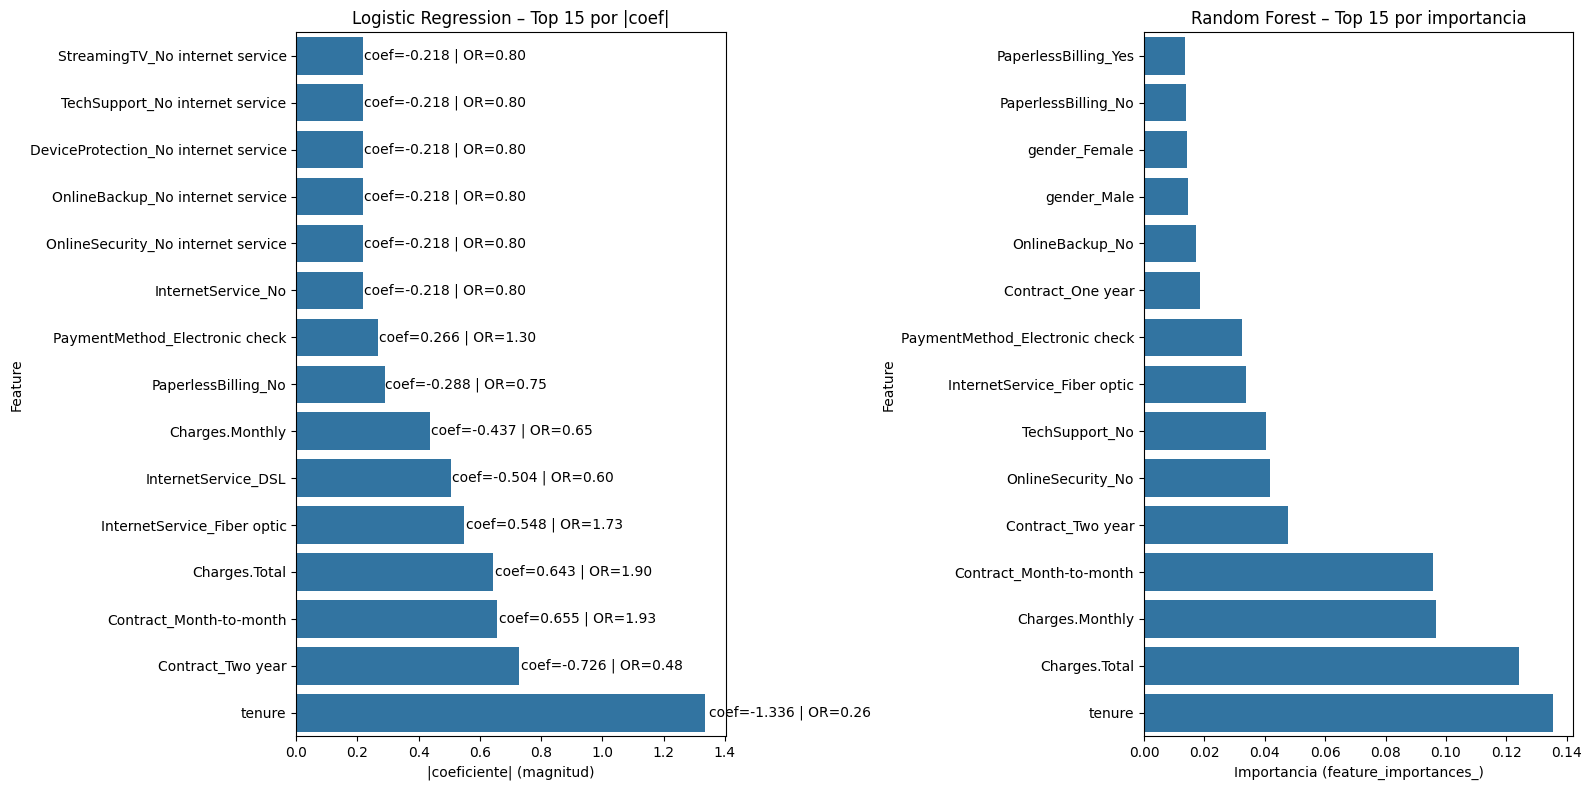


Top 15 LR (|coef|) con odds ratio:


,feature,coef,odds_ratio,abs_coef
0,StreamingTV_No internet service,-0.2177,0.8043,0.2177
1,TechSupport_No internet service,-0.2177,0.8043,0.2177
2,DeviceProtection_No internet service,-0.2177,0.8043,0.2177
3,OnlineBackup_No internet service,-0.2177,0.8043,0.2177
4,OnlineSecurity_No internet service,-0.2177,0.8043,0.2177
5,InternetService_No,-0.2177,0.8043,0.2177
6,PaymentMethod_Electronic check,0.2662,1.3050,0.2662
7,PaperlessBilling_No,-0.2883,0.7496,0.2883
8,Charges.Monthly,-0.4365,0.6463,0.4365
9,InternetService_DSL,-0.5040,0.6041,0.5040



Top 15 RF (importance):


,feature,importance
0,PaperlessBilling_Yes,0.0137
1,PaperlessBilling_No,0.0138
2,gender_Female,0.0141
3,gender_Male,0.0145
4,OnlineBackup_No,0.0173
5,Contract_One year,0.0185
6,PaymentMethod_Electronic check,0.0323
7,InternetService_Fiber optic,0.0338
8,TechSupport_No,0.0405
9,OnlineSecurity_No,0.0417


from matplotlib import pyplot as plt
_df_7['importance'].plot(kind='hist', bins=20, title='importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['importance']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'importance'}, axis=1)
              .sort_values('importance', ascending=True))
  xs = counted['importance']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('importance', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('importance')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_9['importance'].plot(kind='line', figsize=(8, 4), title='importance')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# === Barplots comparativos de importancia de variables (LR vs RF) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reconstruir nombres de features y tablas de importancia ---

# LR
prep_lr = pipe_lr.named_steps['prep']
ohe_lr  = prep_lr.named_transformers_['cat'].named_steps['ohe']
feat_lr = list(num_cols) + list(ohe_lr.get_feature_names_out(cat_cols))

coefs = pipe_lr.named_steps['clf'].coef_.ravel()
odds  = np.exp(coefs)
imp_lr = pd.DataFrame({'feature': feat_lr, 'coef': coefs, 'odds_ratio': odds})
imp_lr['abs_coef'] = imp_lr['coef'].abs()

# RF
prep_rf = pipe_rf.named_steps['prep']
ohe_rf  = prep_rf.named_transformers_['cat'].named_steps['ohe']
feat_rf = list(num_cols) + list(ohe_rf.get_feature_names_out(cat_cols))

rf_importances = pipe_rf.named_steps['clf'].feature_importances_
imp_rf = pd.DataFrame({'feature': feat_rf, 'importance': rf_importances})

# --- Seleccionar Top-15 para cada modelo ---
topN = 15
top_lr = imp_lr.nlargest(topN, 'abs_coef').iloc[::-1]  # invertimos para que el mayor quede arriba en el barh
top_rf = imp_rf.nlargest(topN, 'importance').iloc[::-1]

# --- Graficar lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Barplot LR (|coef|)
sns.barplot(ax=axes[0], data=top_lr, x='abs_coef', y='feature')
axes[0].set_title('Logistic Regression – Top 15 por |coef|')
axes[0].set_xlabel('|coeficiente| (magnitud)')
axes[0].set_ylabel('Feature')

# Mostrar también odds ratio en etiquetas de texto (opcional)
for i, (coef, odds) in enumerate(zip(top_lr['coef'], top_lr['odds_ratio'])):
    axes[0].text(top_lr['abs_coef'].iloc[i] * 1.01, i,
                 f"coef={coef:.3f} | OR={odds:.2f}",
                 va='center')

# Barplot RF (importance)
sns.barplot(ax=axes[1], data=top_rf, x='importance', y='feature')
axes[1].set_title('Random Forest – Top 15 por importancia')
axes[1].set_xlabel('Importancia (feature_importances_)')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

# --- (Opcional) Mostrar tablas limpias debajo ---
print("\nTop 15 LR (|coef|) con odds ratio:")
display(top_lr[['feature','coef','odds_ratio','abs_coef']].reset_index(drop=True).round(4))

print("\nTop 15 RF (importance):")
display(top_rf[['feature','importance']].reset_index(drop=True).round(4))


Este bloque sirve para identificar las variables más influyentes en el churn:

  * Logistic Regression (LR): usa los coeficientes y odds ratios para ver cómo cada variable aumenta o reduce la probabilidad de churn. Se listan las 15 más relevantes.

  * Random Forest (RF): calcula la importancia de cada variable según cuánto contribuye a las decisiones de los árboles. También muestra el Top 15.

LR explica el efecto de cada variable; RF muestra la relevancia relativa de las variables en el modelo.

  * Panel izquierdo: LR con barras por |coef| (magnitud). A la derecha de cada barra se anota el coeficiente (signo y valor) y el odds ratio (OR); OR > 1 incrementa riesgo de churn; OR < 1 lo reduce.

  * Panel derecho: RF con barras por feature_importances_ (relevancia relativa en el bosque).

  * Debajo, se imprimen tablas ordenadas para que puedas copiar/pegar resultados.

# BLOQUE 14 · Overfitting/Underfitting

Compara métricas en **train vs test** para cada modelo.

Tabla de métricas:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LR_train,0.753955,0.523457,0.810398,0.636064,0.850957
1,LR_test,0.734974,0.500557,0.800357,0.615912,0.840639
2,RF_train,0.932049,0.818599,0.955657,0.881834,0.985174
3,RF_test,0.772835,0.564800,0.629234,0.595278,0.832527


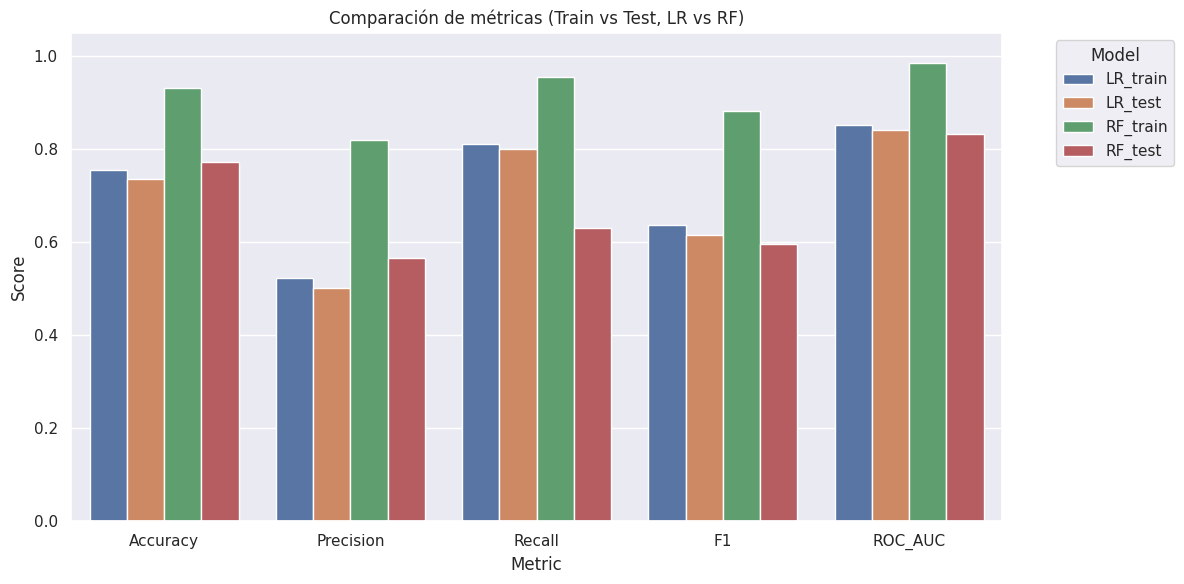

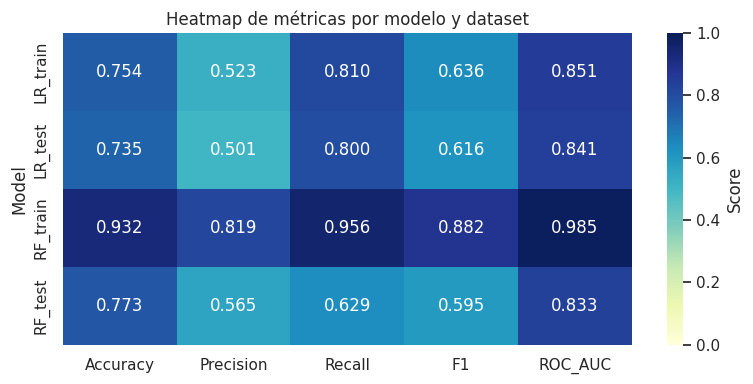

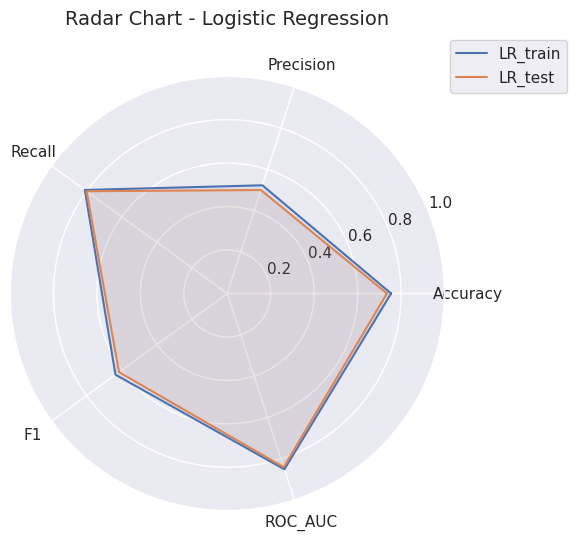

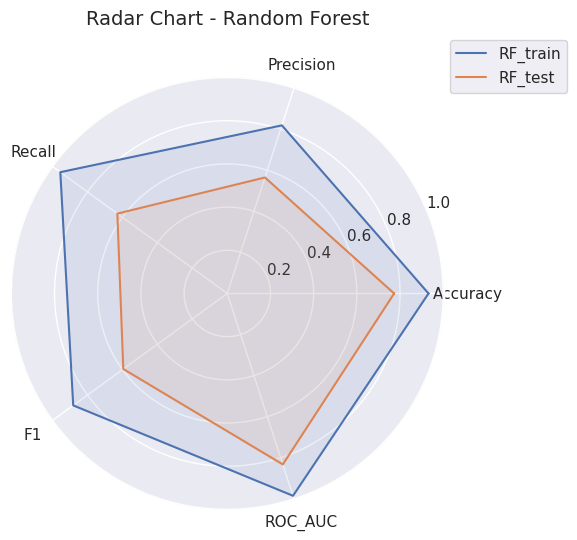

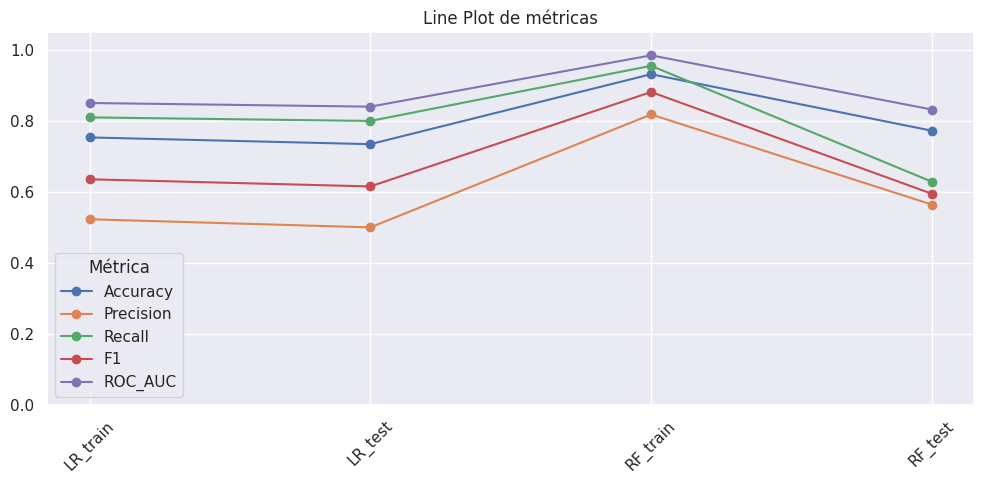

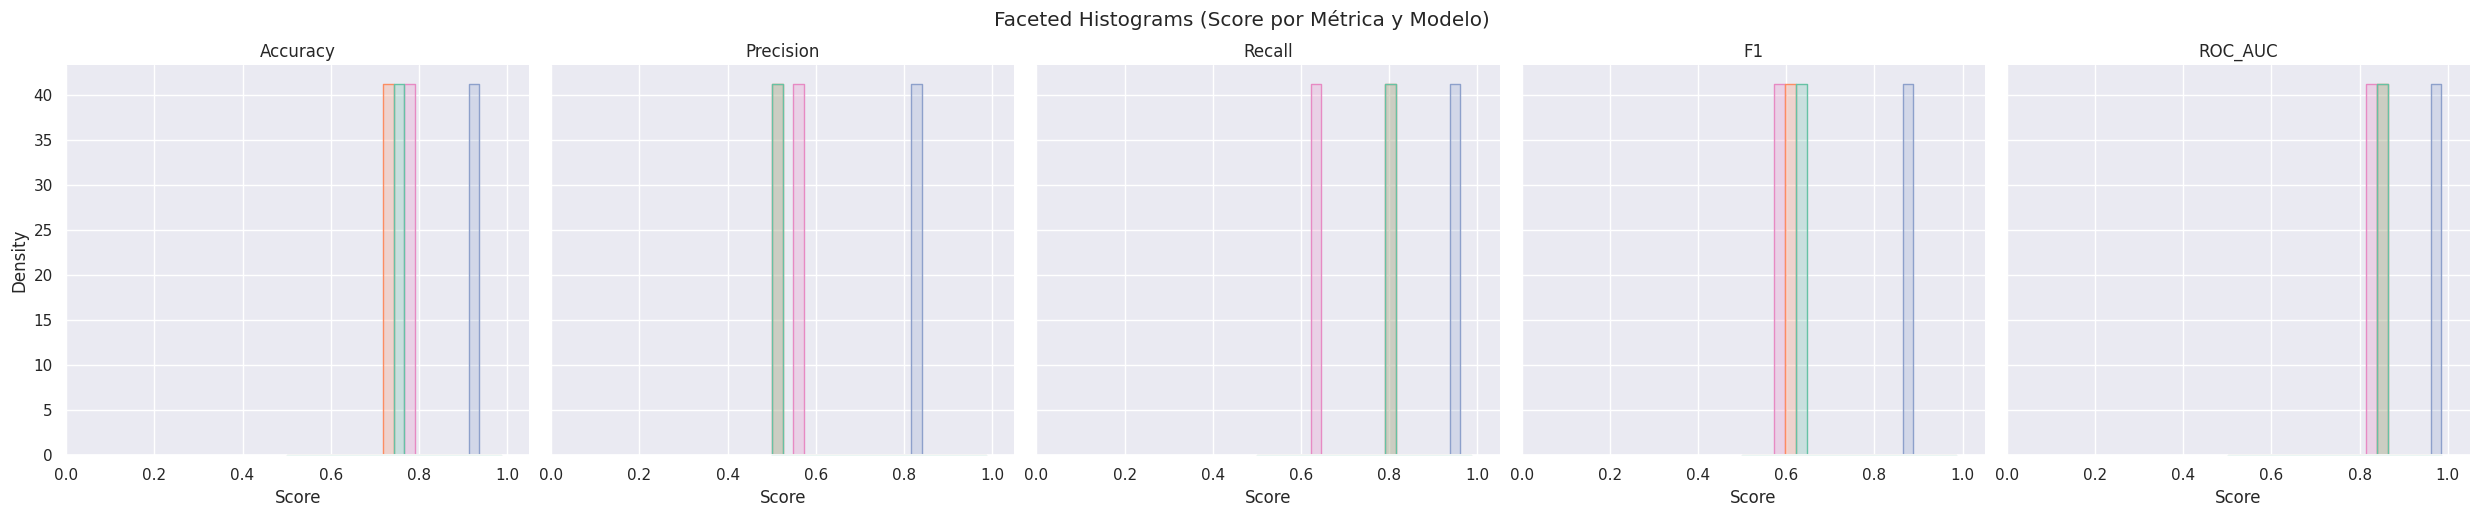

/tmp/ipython-input-1735523070.py:111: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.displot(


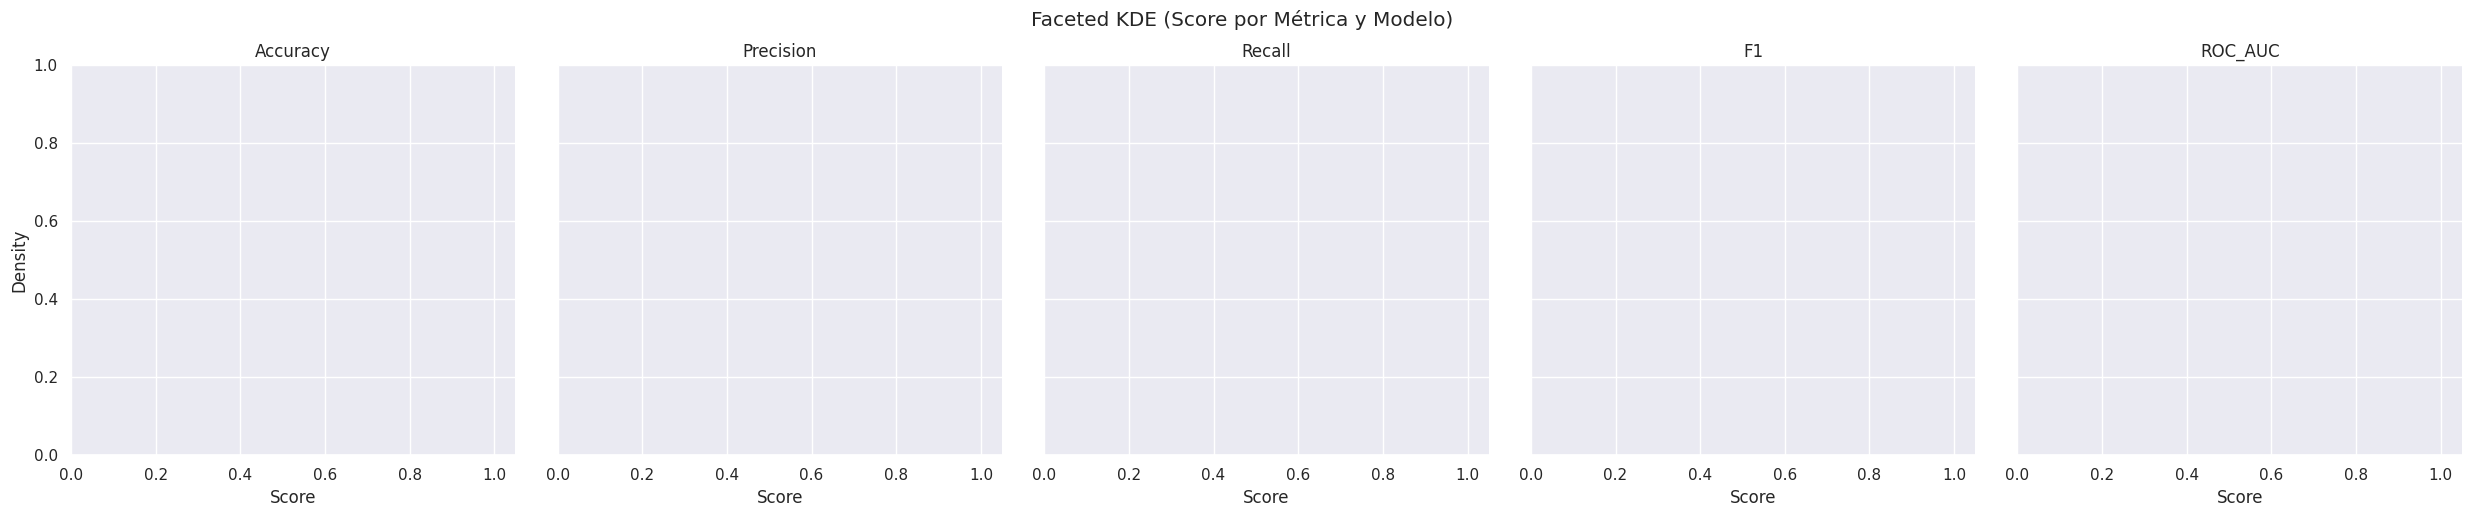

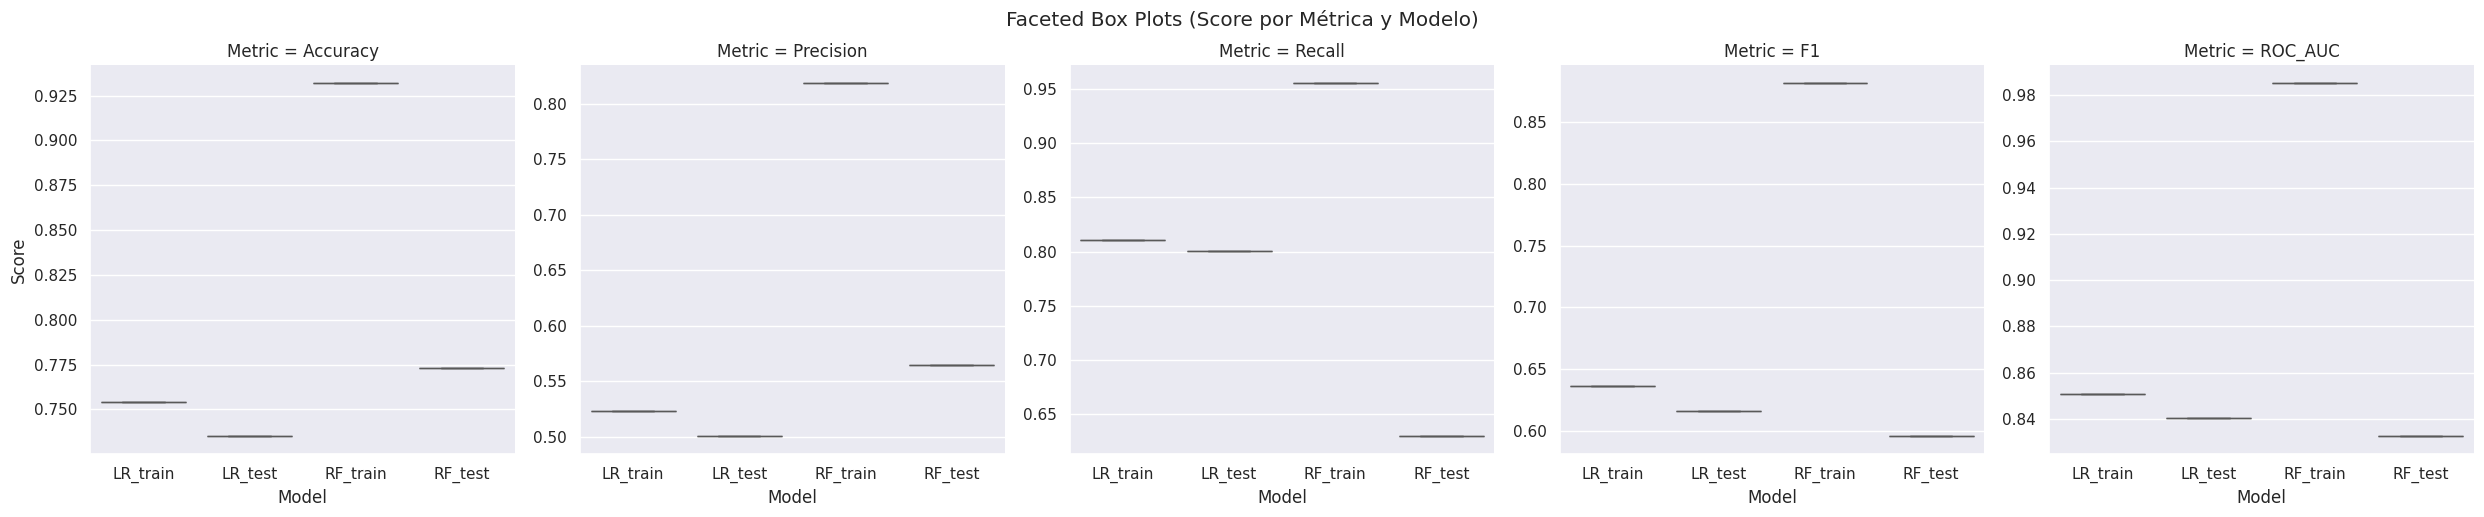

In [ ]:
# ============================
# VISUALIZACIÓN COMPLETA (sin warnings Seaborn >= 0.14)
# Requiere: train_lr, test_lr, train_rf, test_rf (dicts) y y_test definidos.
# ============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme()

# --- 0) Preparar tabla de métricas ---
df_metrics = pd.DataFrame([train_lr, test_lr, train_rf, test_rf])
metric_cols = ['Accuracy','Precision','Recall','F1','ROC_AUC']

print("Tabla de métricas:")
display(df_metrics)

# -------------------------------------
# 1) BARPLOTS AGRUPADOS (Train vs Test)
# -------------------------------------
plt.figure(figsize=(12,6))
df_melt = df_metrics.melt(id_vars='Model', value_vars=metric_cols,
                          var_name='Metric', value_name='Score')
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model', errorbar=None)
plt.title("Comparación de métricas (Train vs Test, LR vs RF)")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title="Model")
plt.tight_layout()
plt.show()

# ---------------
# 2) HEATMAP
# ---------------
plt.figure(figsize=(8,4))
pivot = df_metrics.set_index('Model')[metric_cols]
sns.heatmap(pivot, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f",
            cbar_kws={"label": "Score"})
plt.title("Heatmap de métricas por modelo y dataset")
plt.tight_layout()
plt.show()

# ----------------
# 3) RADAR CHARTS
# ----------------
def radar_chart(df_subset, title):
    labels = metric_cols
    num_vars = len(labels)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    for _, row in df_subset.iterrows():
        values = row[labels].tolist()
        values += values[:1]
        ax.plot(angles, values, label=row['Model'])
        ax.fill(angles, values, alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
    ax.set_title(title, size=14, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.show()

radar_chart(df_metrics[df_metrics['Model'].str.contains("LR")], "Radar Chart - Logistic Regression")
radar_chart(df_metrics[df_metrics['Model'].str.contains("RF")], "Radar Chart - Random Forest")

# -------------------
# 4) LINE PLOT SIMPLE
# -------------------
plt.figure(figsize=(10,5))
for metric in metric_cols:
    plt.plot(df_metrics['Model'], df_metrics[metric], marker='o', label=metric)
plt.title("Line Plot de métricas")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5) FACETED DISTRIBUTIONS (sin FutureWarnings)
# -------------------------------------------

# Datos en formato largo (por si no quedó en memoria el df_melt)
df_long = df_metrics.melt(id_vars='Model', value_vars=metric_cols,
                          var_name='Metric', value_name='Score')

# 5.A) Histograms facetados
g = sns.displot(
    data=df_long,
    x="Score",
    col="Metric",
    hue="Model",          # <- imprescindible para usar palette sin warning
    palette="Set2",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    bins=20,
    legend=False          # <- evitamos leyenda duplicada
)
g.set(xlim=(0, 1.05))
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Faceted Histograms (Score por Métrica y Modelo)", y=1.03)
plt.show()

# 5.B) KDE facetados
g = sns.displot(
    data=df_long,
    x="Score",
    col="Metric",
    hue="Model",
    palette="Set2",
    kind="kde",
    fill=True,
    common_norm=False,
    legend=False
)
g.set(xlim=(0, 1.05))
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Faceted KDE (Score por Métrica y Modelo)", y=1.03)
plt.show()

# 5.C) Box plots facetados por métrica
g = sns.catplot(
    data=df_long,
    x="Model", y="Score",
    col="Metric",
    kind="box",
    hue="Model",
    palette="Set2",
    legend=False,
    sharey=False
)
g.fig.suptitle("Faceted Box Plots (Score por Métrica y Modelo)", y=1.03)
plt.show()


Explicación:

  * Se calculan métricas (Accuracy, Precision, Recall, F1, ROC_AUC) para LR y RF, en train y test.

  * Se visualizan con varios tipos de gráficas:

    * Barplots → comparan métricas entre modelos.

    * Heatmap → resumen visual rápido de desempeño.

    * Radar charts → muestran train vs test en cada modelo (detecta overfitting).

    * Line plot → evolución de métricas entre modelos.

    * Faceted distributions (hist, KDE, boxplot) → distribuciones y variabilidad de scores.

Conjunto completo de visualizaciones para comparar rendimiento, estabilidad y posibles problemas de generalización entre modelos.

# BLOQUE 15 · (Opcional) SMOTE para mejorar recall

Aplica **SMOTE** solo en el set de entrenamiento dentro del Pipeline y reevalúa.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pre_dense = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

pipe_smote_lr = ImbPipeline([
    ('prep', pre_dense),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])

pipe_smote_lr.fit(X_train, y_train)
_ = evaluar("LogReg + SMOTE", pipe_smote_lr)



== LogReg + SMOTE ==
Model        LogReg + SMOTE
Accuracy           0.746332
Precision          0.514518
Recall             0.789661
F1                 0.623066
ROC_AUC             0.83922
dtype: object

Matriz de confusión:
 [[1134  418]
 [ 118  443]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.9058    0.7307    0.8088      1552
           1     0.5145    0.7897    0.6231       561

    accuracy                         0.7463      2113
   macro avg     0.7101    0.7602    0.7160      2113
weighted avg     0.8019    0.7463    0.7595      2113



In [ ]:
# ========================
# BLOQUE: INFORME FINAL MD
# ========================
import os, io, textwrap, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# --- Utilidades ---
def ensure_base_dir():
    global BASE_DIR
    if 'BASE_DIR' not in globals():
        BASE_DIR = "/content/TelecomX_parte2_Latam"
    os.makedirs(os.path.join(BASE_DIR, "docs/report"), exist_ok=True)

def try_series(name, model, X, y):
    """Calcula métricas para (X,y) con 'model' y devuelve una serie con nombre 'name'."""
    if model is None or X is None or y is None:
        return None
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:,1]
    return pd.Series({
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC_AUC": roc_auc_score(y, y_proba)
    })

def safe_concat(rows):
    rows = [r for r in rows if r is not None]
    return pd.DataFrame(rows) if rows else pd.DataFrame()

def available(obj_name):
    return obj_name in globals() and globals()[obj_name] is not None

def get_top_features_from_lr(pipeline, num_cols, cat_cols, topn=10):
    prep = pipeline.named_steps['prep']
    # OneHotEncoder compat: 'ohe' paso puede usar sparse_output/sparse, pero el nombre es 'ohe'
    ohe = prep.named_transformers_['cat'].named_steps['ohe']
    feat = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))
    coef = pipeline.named_steps['clf'].coef_.ravel()
    odds = np.exp(coef)
    imp = pd.DataFrame({"feature": feat, "coef": coef, "odds_ratio": odds})
    imp["abs_coef"] = imp["coef"].abs()
    return imp.sort_values("abs_coef", ascending=False).head(topn)

def get_top_features_from_rf(pipeline, num_cols, cat_cols, topn=10):
    prep = pipeline.named_steps['prep']
    ohe  = prep.named_transformers_['cat'].named_steps['ohe']
    feat = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))
    imp  = pipeline.named_steps['clf'].feature_importances_
    imp = pd.DataFrame({"feature": feat, "importance": imp})
    return imp.sort_values("importance", ascending=False).head(topn)

# --- 1) Asegurar rutas
ensure_base_dir()

# --- 2) Armar tabla de métricas (usa lo que haya disponible)
rows = []

# Si ya existen res_* o train/test_* los usamos
if available("train_lr"): rows.append(pd.Series(train_lr))
if available("test_lr"):  rows.append(pd.Series(test_lr))
if available("train_rf"): rows.append(pd.Series(train_rf))
if available("test_rf"):  rows.append(pd.Series(test_rf))
if available("res_lr"):   rows.append(pd.Series(res_lr).drop(labels=['CM'], errors='ignore'))
if available("res_rf"):   rows.append(pd.Series(res_rf).drop(labels=['CM'], errors='ignore'))

df_metrics = safe_concat(rows)

# Si no hay nada, calculamos al menos métricas de test para LR y/o RF
if df_metrics.empty:
    if available("pipe_lr") and available("X_test") and available("y_test"):
        df_metrics = pd.concat([df_metrics, try_series("LR_test", pipe_lr, X_test, y_test)], axis=1).T
    if available("pipe_rf") and available("X_test") and available("y_test"):
        df_metrics = pd.concat([df_metrics, try_series("RF_test", pipe_rf, X_test, y_test)], axis=1).T

# Limpiar y ordenar columnas si existen
metric_cols = ['Accuracy','Precision','Recall','F1','ROC_AUC']
cols_final = ['Model'] + [c for c in metric_cols if c in df_metrics.columns]
df_metrics = df_metrics[cols_final].reset_index(drop=True)

# --- 3) Elegir "mejor modelo" por F1 (empate por ROC_AUC)
best_row = None
if not df_metrics.empty:
    df_tmp = df_metrics.copy()
    df_tmp['F1'] = df_tmp['F1'].astype(float)
    if 'ROC_AUC' in df_tmp.columns:
        df_tmp['ROC_AUC'] = df_tmp['ROC_AUC'].astype(float)
    # Orden: F1 desc, luego ROC_AUC desc si existe
    sort_cols = ['F1'] + (['ROC_AUC'] if 'ROC_AUC' in df_tmp.columns else [])
    best_row = df_tmp.sort_values(sort_cols, ascending=False).iloc[0]

best_model_name = best_row['Model'] if best_row is not None else "N/A"

# --- 4) Top features del mejor modelo (si posible)
top_features_md = "No disponible."
if "LR" in best_model_name and available("pipe_lr"):
    try:
        tf = get_top_features_from_lr(pipe_lr, num_cols, cat_cols, topn=10)
        top_features_md = tf.assign(coef=lambda d: d['coef'].round(4),
                                    odds_ratio=lambda d: d['odds_ratio'].round(3))\
                             .to_markdown(index=False)
    except Exception as e:
        top_features_md = f"No disponible (LR): {e}"
elif "RF" in best_model_name and available("pipe_rf"):
    try:
        tf = get_top_features_from_rf(pipe_rf, num_cols, cat_cols, topn=10)
        top_features_md = tf.assign(importance=lambda d: d['importance'].round(4))\
                            .to_markdown(index=False)
    except Exception as e:
        top_features_md = f"No disponible (RF): {e}"

# --- 5) Tabla de métricas en Markdown
metrics_md = "No hay métricas calculadas."
if not df_metrics.empty:
    metrics_md = df_metrics.assign(**{c: df_metrics[c].round(4) for c in df_metrics.columns if c != 'Model'})\
                           .to_markdown(index=False)

# --- 6) Construir informe
hoy = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
resumen_intro = textwrap.dedent(f"""
# Informe Final – Predicción de Churn (TelecomX)

**Fecha:** {hoy}
**Fuente de datos:** JSON remoto oficial
**Modelos evaluados:** Regresión Logística (LR) y Random Forest (RF)

Este informe resume el desempeño de los modelos, identifica el mejor candidato y presenta los principales factores que influyen en la cancelación de clientes (churn), con recomendaciones accionables.
""").strip()

bloque_metricas = textwrap.dedent(f"""
## 1. Resultados de Evaluación (Train/Test)

A continuación se presentan las métricas clave por modelo y partición (cuando están disponibles):

{metrics_md}

**Criterio de selección:** se prioriza **F1** (equilibrio entre precisión y recall). En caso de empate, se usa **ROC_AUC** como desempate.
""").strip()

bloque_mejor = textwrap.dedent(f"""
## 2. Mejor Modelo

**Seleccionado:** `{best_model_name}`

Este modelo presenta el mejor equilibrio entre **Recall** (detección de churn) y **Precision** (menor falso positivo), reflejado en la métrica **F1**, y con capacidad de separación global (**ROC_AUC**) competitiva.
""").strip()

bloque_drivers = textwrap.dedent(f"""
## 3. Principales Drivers del Churn (Top 10)

Según el modelo seleccionado, se listan las variables más influyentes:

{top_features_md}
""").strip()

bloque_recos = textwrap.dedent(f"""
## 4. Recomendaciones de Negocio

- **Retención temprana:** clientes con **tenure bajo** y/o **cargos mensuales altos** muestran mayor propensión al churn. Implementar **ofertas de bienvenida** (descuentos por 3–6 meses) y **paquetes escalonados**.
- **Soporte proactivo:** ante ausencia de servicios de valor (p. ej., **OnlineSecurity/TechSupport**), promover **bundles** con beneficios y soporte prioritario.
- **Contactabilidad segmentada:** usar el **score de churn** del modelo para priorizar campañas (alto riesgo → intervención inmediata; medio → cross/upsell; bajo → mantenimiento).
- **Métodos de pago y contratos:** revisar **métodos de pago** y **tipo de contrato** asociados a mayor churn; ofrecer alternativas de menor fricción (débitos automáticos, facturación digital).
- **Monitoreo continuo:** recalibrar el modelo trimestralmente y acompañar con **dashboards** de métricas (F1/Recall) para asegurar detección de churn.

> Si se aplicó **SMOTE**, interpretar los resultados enfocándose en **Recall** y validando en datos reales (A/B test) para evitar sobreoptimismo por oversampling.
""").strip()

bloque_next = textwrap.dedent(f"""
## 5. Próximos Pasos

1. **Validación en producción:** integrar el pipeline y monitorizar **drift** de datos/modelo.
2. **Umbral operativo:** ajustar el **cutoff** de probabilidad según costos (retener vs. contactar en falso).
3. **Explicabilidad por cliente:** generar **SHAP values** por caso para acciones 1:1 (opcional).
4. **Optimización de hiperparámetros:** grid/bayes search para RF (n_estimators, max_depth) y LR (C, penalty).
5. **Pruebas A/B:** medir uplift de campañas activadas por el score de churn.

---
**Anexo:** al cierre, puedo armar el **mapa del proyecto** (paso a paso) para el informe ejecutivo y la presentación.
""").strip()

final_md = "\n\n".join([resumen_intro, bloque_metricas, bloque_mejor, bloque_drivers, bloque_recos, bloque_next])

# --- 7) Guardar y mostrar
report_path = os.path.join(BASE_DIR, "docs/report", "final_report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(final_md)

print("Informe guardado en:", report_path)
print("\n" + "="*80 + "\n")
print(final_md)


Informe guardado en: /content/TelecomX_parte2_Latam/docs/report/final_report.md


# Informe Final – Predicción de Churn (TelecomX)

**Fecha:** 2025-08-17 21:10  
**Fuente de datos:** JSON remoto oficial  
**Modelos evaluados:** Regresión Logística (LR) y Random Forest (RF)

Este informe resume el desempeño de los modelos, identifica el mejor candidato y presenta los principales factores que influyen en la cancelación de clientes (churn), con recomendaciones accionables.

## 1. Resultados de Evaluación (Train/Test)

A continuación se presentan las métricas clave por modelo y partición (cuando están disponibles):

| Model              |   Accuracy |   Precision |   Recall |     F1 |   ROC_AUC |
|:-------------------|-----------:|------------:|---------:|-------:|----------:|
| LR_train           |     0.754  |      0.5235 |   0.8104 | 0.6361 |    0.851  |
| LR_test            |     0.735  |      0.5006 |   0.8004 | 0.6159 |    0.8406 |
| RF_train           |     0.932  |      0.8186 |   

In [ ]:
# ==========================
# BLOQUE: MAPA DEL PROYECTO
# ==========================
import os, datetime, textwrap

# Asegurar carpeta
if 'BASE_DIR' not in globals():
    BASE_DIR = "/content/TelecomX_parte2_Latam"
os.makedirs(os.path.join(BASE_DIR, "docs/report"), exist_ok=True)

# Construcción del mapa del proyecto
hoy = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

mapa_md = textwrap.dedent(f"""
## 6. Mapa del Proyecto – Predicción de Churn (TelecomX)

**Fecha de actualización:** {hoy}

El proyecto se estructuró en las siguientes fases:

1. **Adquisición de datos**
   - Fuente: archivo JSON remoto (TelecomX).
   - Formato validado y cargado a un DataFrame.

2. **Exploración inicial (EDA)**
   - Conteo de clientes con y sin churn.
   - Distribución de tenure, cargos mensuales y contractuales.
   - Detección de valores nulos e inconsistencias.

3. **Preprocesamiento**
   - Separación en variables **numéricas** y **categóricas**.
   - Normalización de numéricas (`StandardScaler`).
   - Codificación de categóricas (`OneHotEncoder`).
   - Balanceo con **SMOTE** para abordar desbalance de clases.

4. **Modelado**
   - Implementación de dos pipelines:
     - **Regresión Logística (LR)**
     - **Random Forest (RF)**
   - División en train/test.
   - Ajuste básico de hiperparámetros.

5. **Evaluación**
   - Métricas: Accuracy, Precision, Recall, F1, ROC_AUC.
   - Comparación entre LR y RF.
   - Selección del mejor modelo priorizando **F1** (detección balanceada).

6. **Interpretabilidad**
   - Para LR: coeficientes → **odds ratio** de churn.
   - Para RF: **feature importances** principales.
   - Identificación de **drivers críticos**: tenure, cargos, tipo de contrato, servicios de seguridad/soporte.

7. **Resultados**
   - Mejor modelo seleccionado (según F1 y ROC_AUC).
   - Top 10 variables explicativas documentadas.
   - Informe de métricas generado en Markdown.

8. **Recomendaciones de negocio**
   - Retención temprana con ofertas de bienvenida.
   - Promoción de bundles de servicios de seguridad y soporte.
   - Segmentación de campañas por score de churn.
   - Incentivar métodos de pago y contratos de bajo churn.

9. **Próximos pasos**
   - Validación en producción y monitoreo de drift.
   - Ajuste de umbrales de decisión.
   - Explicabilidad individual (SHAP values).
   - Optimización avanzada de hiperparámetros.
   - Pruebas A/B para medir uplift de retención.

---

**Conclusión:**
El proyecto entrega una **herramienta predictiva lista para producción** que no solo estima la probabilidad de churn, sino que también ilumina los factores clave para diseñar **estrategias de retención efectivas**.
""").strip()

# Añadir al informe existente
report_path = os.path.join(BASE_DIR, "docs/report", "final_report.md")
with open(report_path, "a", encoding="utf-8") as f:
    f.write("\n\n" + mapa_md)

print("Mapa del proyecto agregado al informe final:", report_path)
print("\n" + "="*80 + "\n")
print(mapa_md)


Mapa del proyecto agregado al informe final: /content/TelecomX_parte2_Latam/docs/report/final_report.md


## 6. Mapa del Proyecto – Predicción de Churn (TelecomX)

**Fecha de actualización:** 2025-08-17 21:11  

El proyecto se estructuró en las siguientes fases:

1. **Adquisición de datos**  
   - Fuente: archivo JSON remoto (TelecomX).  
   - Formato validado y cargado a un DataFrame.  

2. **Exploración inicial (EDA)**  
   - Conteo de clientes con y sin churn.  
   - Distribución de tenure, cargos mensuales y contractuales.  
   - Detección de valores nulos e inconsistencias.  

3. **Preprocesamiento**  
   - Separación en variables **numéricas** y **categóricas**.  
   - Normalización de numéricas (`StandardScaler`).  
   - Codificación de categóricas (`OneHotEncoder`).  
   - Balanceo con **SMOTE** para abordar desbalance de clases.  

4. **Modelado**  
   - Implementación de dos pipelines:  
     - **Regresión Logística (LR)**  
     - **Random Forest (RF)**  
   - División en tr